In [1]:
import numpy as np
from numpy import linalg as la

array = np.array([1,2,3,0,-4,1,0,3,1]).reshape(3,3)
det = la.det(array)
Ainv = la.inv(array)
print(array, f'the det of A is {det:.3f}')

b = np.array([10,8,3])
X = la.solve(array, b) 
print(X)

ortho = array@Ainv
print(ortho, f'this is orthognal!')

Lambda, v = la.eig(array)
print(Lambda)

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3  1]] the det of A is -7.000
[-4.         -0.71428571  5.14285714]
[[ 1.00000000e+00  5.55111512e-17 -2.22044605e-16]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] this is orthognal!
[ 1.         -4.54138127  1.54138127]


In [2]:
import numpy as np
from numpy import linalg as la
import math as m

a = m.radians(57)
b = m.radians(62.6)
c = m.radians(192.25)

Ez = np.array([np.cos(a), np.sin(a), 0, -np.sin(a), np.cos(a), 0, 0, 0, 1]).reshape(3,3)
Ey = np.array([np.cos(b), 0, -np.sin(b), 0, 1, 0, np.sin(b), 0, np.cos(b)]).reshape(3,3)
Ez2 = np.array([np.cos(c), np.sin(c), 0, -np.sin(c), np.cos(c), 0, 0, 0, 1]).reshape(3,3)

c = Ez@Ey@Ez2
Lambda, v_ = la.eig(c)
print(Ez@Ey@Ez2)

print(Lambda)
#the rotation matrix has an eigenvalue of 1, so it is a rotation matrix. This means it does not change the length of any of the vectors
v = np.array([-0.86760081, -0.1883746, 0.46019978]).reshape(3,1)

print(f'{c@v} is the rotation of v, which (when rounded) gives you [0,0,1], which is the pole')


[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[[ 7.32356596e-10]
 [-3.77054961e-09]
 [ 9.99999996e-01]] is the rotation of v, which (when rounded) gives you [0,0,1], which is the pole


[[-2.17117476e-04]
 [ 1.09925609e-02]
 [-2.39059756e-01]
 [ 2.91867714e+00]
 [-2.19331359e+01]
 [ 1.04544074e+02]
 [-3.13633556e+02]
 [ 5.65812237e+02]
 [-5.51003146e+02]
 [ 2.18582332e+02]]


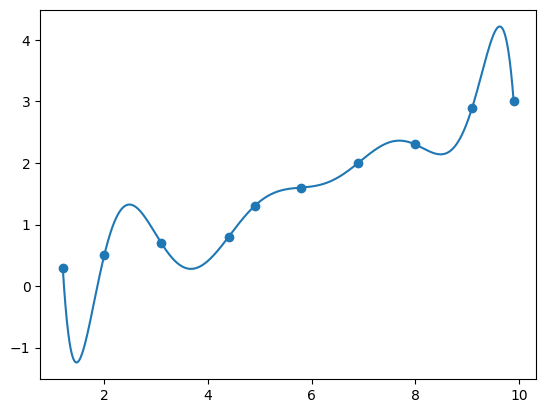

In [3]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


A = []

for i in range(len(x)):
    k = len(x)-1
    while k >= 0:
        c = x[i]**k
        k = k-1
        A.append(c)


Array = np.array(A).reshape(10, 10)
y = y.reshape(len(y), 1)

coefficients = la.solve(Array, y)
print(coefficients)

newx = np.linspace(np.min(x), np.max(x), len(x)*100)


newy = 0
for i in range (len(coefficients)):
    newy = newy + coefficients[i]*newx**((len(x)-1)-i)
        


fig, ax = plt.subplots()
ax.plot(newx, newy)
ax.scatter(x, y)
#the plots are similar!

what kind of interpolation linear
whats X? 6
1.6727272727272728
what kind of interpolation spline
whats X? 6
1.6545989842119568
what kind of interpolation poly
whats X? 6
[1.61737591]


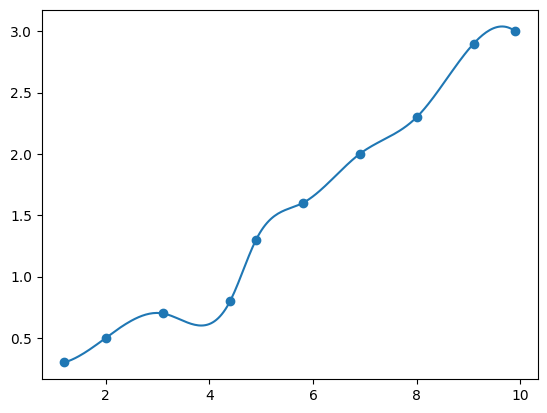

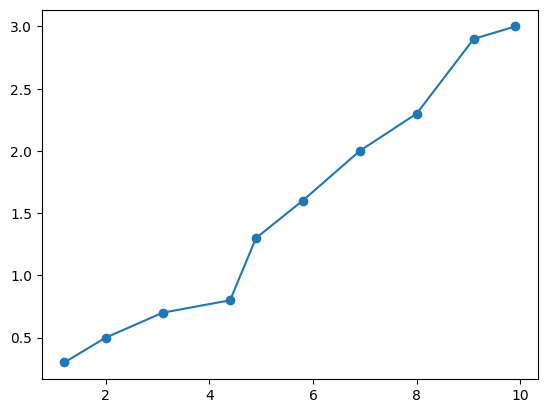

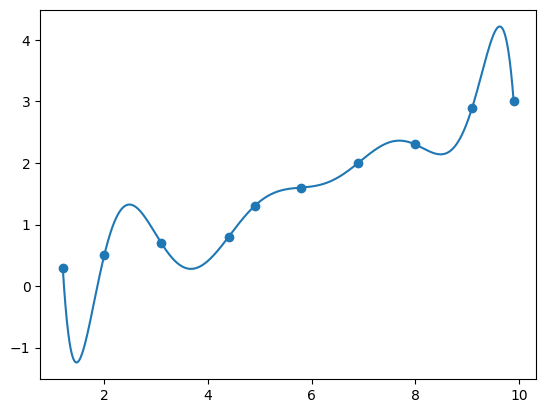

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip



class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def interpolate_spline(self):
        f = ip.interp1d(self.x, self.y, kind = 'cubic') 
        newx = np.linspace(np.min(self.x), np.max(self.x), 250)
        newy = f(newx)
        fig, ax = plt.subplots()
        ax.plot(newx, newy)
        ax.scatter(self.x, self.y)
    
    
    def Linear(self):
        f = ip.interp1d(self.x, self.y, kind = 'linear')
        newx = np.linspace(np.min(self.x), np.max(self.x), 250)
        newy = f(newx)
        fig, ax = plt.subplots()
        ax.plot(newx, newy)
        ax.scatter(x, y)
        
    def ploy(self):
        A = []

        for i in range(len(x)):
            k = len(self.x)-1
            while k >= 0:
                c = self.x[i]**k
                k = k-1
                A.append(c)

        Array = np.array(A).reshape(10, 10)
        b = self.y.reshape(len(y), 1)

        coefficients = la.solve(Array, b)
        newx = np.linspace(np.min(self.x), np.max(self.x), len(self.x)*100)

        newy = 0
        for i in range (len(coefficients)):
            newy = newy + coefficients[i]*newx**((len(self.x)-1)-i)
    
        fig, ax = plt.subplots()
        ax.plot(newx, newy)
        ax.scatter(self.x, b)
        
        
        
    def X_hat(self):
        interp = input('what kind of interpolation ')
        X = float(input("whats X? "))
        if interp == 'poly':
            A = []

            for i in range(len(x)):
                k = len(self.x)-1
                while k >= 0:
                    c = self.x[i]**k
                    k = k-1
                    A.append(c)

            Array = np.array(A).reshape(10, 10)
            b = self.y.reshape(len(y), 1)

            coefficients = la.solve(Array, b)
            newx = np.linspace(np.min(self.x), np.max(self.x), len(self.x)*100)

            newy = 0
            for i in range (len(coefficients)):
                newy = newy + coefficients[i]*X**((len(self.x)-1)-i)
       
            return newy
    
        elif interp == 'spline':
            f = ip.interp1d(self.x, self.y, kind = 'cubic') 
            newx = np.linspace(np.min(self.x), np.max(self.x), 250)
            return f(X)
            
        
        elif interp == 'linear':
            k = ip.interp1d(self.x, self.y, kind = 'linear')
            return k(X)
        
U = interpolation(x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9]),y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0]))

U.interpolate_spline()
U.Linear()
U.ploy()
print(U.X_hat())
print(U.X_hat())
print(U.X_hat())

In [22]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)




I = np.array([[2.0,4.1], [2.5,3.8]])
x = 0.2
Iip = linearIP(I, x)
print(f"The interpolated intensity at x={x} is {Iip}")


I = np.array([[2.0,4.1], [2.5,3.8]])
x = 0.7
Iip = linearIP(I, x)
print(f"The interpolated intensity at x={x} is {Iip}")


The interpolated intensity at x=0.2 is [2.1  4.04]
The interpolated intensity at x=0.7 is [2.35 3.89]


====== LEASTSQ RESULTS ==========
Params:                          [69.93819296 64.13233139]
Unscaled standard error(s):      [47.32288576  1.52711812]
Scaled standard error(s):        [348.23439861  11.23758733]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328985
Reduced Chi squared:             54.150303702990776
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7
Intercept beta0=9.189492762469122, slope beta1=71.382962460222
[69.93819296 64.13233139]


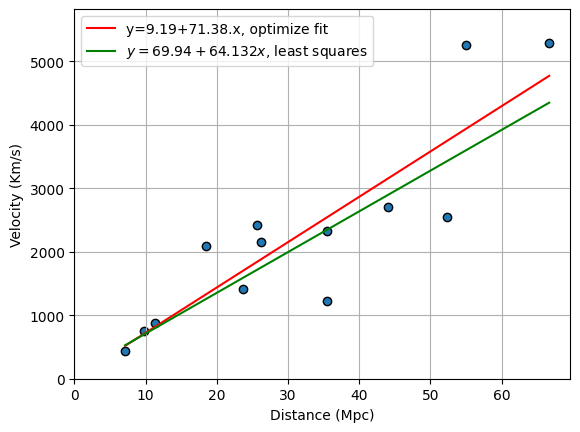

In [23]:
import numpy as np
from scipy.optimize import curve_fit
data = np.array([
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
])

data_new = data.reshape(13,4)

x = data[0::4]
y = data[1::4]
errx = data[2::4]
erry = data[3::4]


def model(beta, x):
    beta0, beta1 = beta              # Parameters which are adjusted by leastsq
    return beta0 + beta1*x

def residuals(beta, x, y):           # Residuals function needed by leastsq
    x, y = data
    return y - model(beta,x)

from scipy.optimize import leastsq

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, erry)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

# Convert unscaled standard errors to scaled standard errors
# No need to understand this code
if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsqwei = beta




from matplotlib.pyplot import figure, show




def model2(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

# Do the fitting
beta, pcov = curve_fit(model2, x, y)
print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")

# Calculate end points for the best straight line
X = np.array([x.min(),x.max()])
Y = model2(X, beta[0], beta[1])

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k')
frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (Km/s)')
label = f"y={beta[0]:.2f}+{beta[1]:.2f}.x, optimize fit"
frame.plot(X, Y, label=label, color='red')
frame.legend(fancybox=True, framealpha=0.5)




xmin = x.min(); xmax = x.max()
ymin = model(beta_lsqwei,xmin); ymax = model(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label=r"$y = 69.94 + 64.132x$, least squares", color='green')
print(beta_lsqwei)
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()


show()
